# Starlink as a school connectivity provider

Starlink is the only access technology in this dataset that a ministry can buy
without building anything, which makes "is it good enough for a school" a
procurement question rather than an academic one. This notebook takes it
exploratorily: how far adoption has gone, how the routing differs from the
terrestrial operators in the same country, and where it wins and loses.

**Questions answered**
- **Q1** — how has adoption moved, country by country and month by month?
- **Q2** — how does Starlink routing differ from terrestrial in the same country?
- **Q3** — latency, throughput and loss: where does it win, where does it lose?
- **Q4** — is its capacity contended across the school day?
- **Q5** — does it get worse as more schools join it?

Adoption comes from Giga Meter, which covers more countries than the traceroute
exports; routing needs both.

---
## Part 0 — Identifying Starlink

Worth stating, because keying on the wrong field loses most of the data. The
measurements carry `AS14593` and `AS1459` under an identical operator name —
the second is almost certainly a corrupted ASN string rather than a different
network — and some rows carry no ASN at all. The operator name is the field
that is consistent, but it arrives with a trailing space on most rows, so an
equality test silently drops the majority. Everything here matches by
lowercased substring on the name.

In [1]:
# =============================================================================
# REPOSITORY ROOT
# =============================================================================
# These notebooks live in traceroutes/ but read helpers/, data/ and cache/ from
# the repository root, so resolve it and work from there. Idempotent, and it
# means the notebook runs the same whether it is launched from this folder or
# from the root.
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'helpers').is_dir() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
print(f'working from {_root}')

# =============================================================================
# IMPORTS
# =============================================================================
import sys
import json
import logging
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, 'helpers')
from starlink import (penetration, adoption_summary, compare_routing,
                      congestion_profile, congestion_summary, is_starlink,
                      ground_station_handoff, within_school_comparison,
                      within_school_verdict, STARLINK_PATTERNS)
from load_traceroutes import load_traceroutes

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
from giga_chart_style import *
pd.set_option('display.width', 220)

REF = json.load(open('helpers/country_reference.json'))
NAME = {k: v['name'] for k, v in REF.items()}

# Countries with both Starlink and terrestrial traceroutes, for Q2-Q4.
COMPARE = {'MW': 'MWI', 'FJ': 'FJI', 'BW': 'BWA', 'KZ': 'KAZ', 'MN': 'MNG', 'KE': 'KEN'}
print("matching on:", STARLINK_PATTERNS)


working from /Users/mariaabravoreyes/Documents/Giga/gigameter-explorer


matching on: ('space explor', 'starlink', 'spacex')


---
## Q1 — Where has Starlink reached schools?

Counted in schools rather than tests: one school testing heavily would
otherwise read as adoption. The denominator is schools *measuring* in that
country-month, not the school census — Giga Meter does not cover every school,
so this is penetration of the measured estate.

**Read these curves as deployment, not adoption.** In Malawi the Starlink
schools are a Giga programme fleet: they were selected and connected, not won
in a market. A rising line there is a rollout schedule. It also means the
Starlink and terrestrial estates are not comparable populations, which Q5
takes up and which changes the answer.

In [2]:
# =============================================================================
# Q1 — ADOPTION BY COUNTRY
# =============================================================================
pen = penetration()
summary = adoption_summary(pen)
summary.insert(1, 'country', summary['iso3'].map(lambda c: NAME.get(c, c)[:22]))
display(summary)

print(f"Countries where Starlink has ever served a measuring school: "
      f"{pen[pen['schools_starlink'] > 0]['iso3_code'].nunique()} of "
      f"{pen['iso3_code'].nunique()}")

,iso3,country,first_seen,months_present,months_observed,schools_latest,schools_total_latest,share_latest_pct,share_peak_pct,peak_month,latest_month
0,MWI,Malawi,2025-06,15,15,59,93,63.4,63.4,2026-08,2026-08
1,MEX,Mexico,2026-07,2,2,4,11,36.4,70.0,2026-07,2026-08
2,KAZ,Kazakhstan,2024-02,30,43,71,380,18.7,20.3,2026-05,2026-08
3,BWA,Botswana,2024-10,23,43,16,92,17.4,18.3,2025-12,2026-08
4,FJI,Fiji,2024-07,26,29,52,340,15.3,15.3,2026-08,2026-08
5,KEN,Kenya,2024-07,26,26,8,72,11.1,21.1,2025-11,2026-08
6,DMA,Dominica,2026-06,1,2,1,10,10.0,10.0,2026-06,2026-06
7,RWA,Rwanda,2023-10,13,39,2,30,6.7,11.8,2026-05,2026-08
8,HND,Honduras,2025-10,10,14,2,31,6.5,7.5,2026-03,2026-08
9,MNG,Mongolia,2023-09,33,44,24,570,4.2,6.9,2025-11,2026-08


Countries where Starlink has ever served a measuring school: 18 of 37


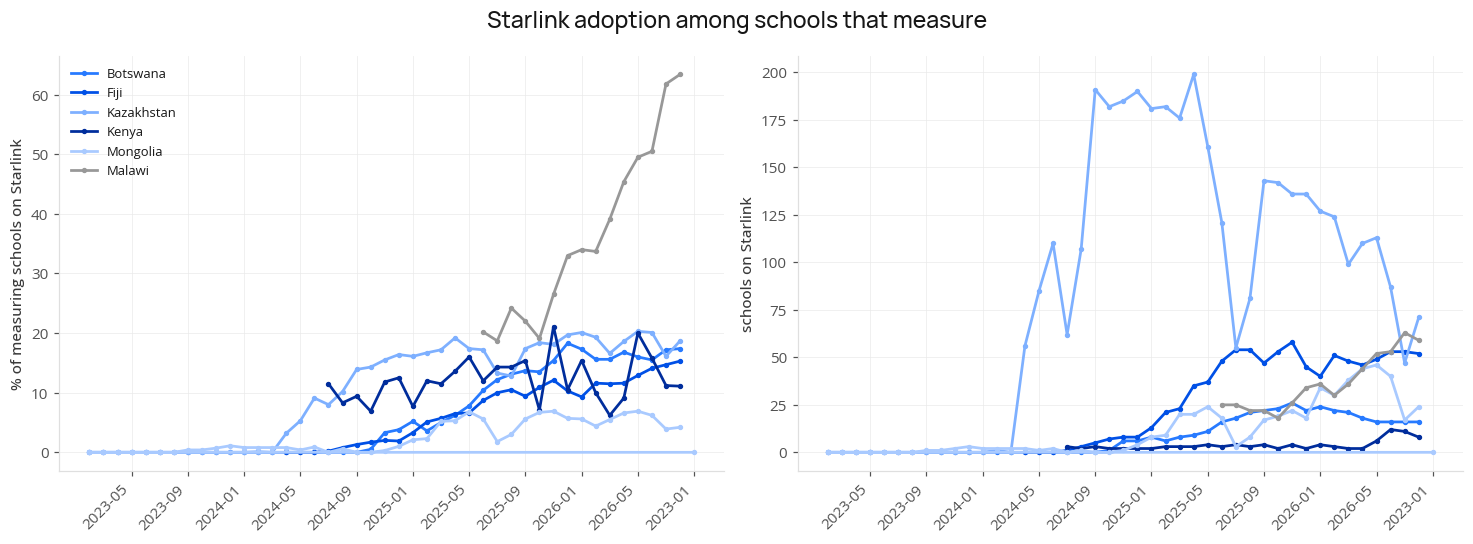

Malawi is the outlier: a fifth of measuring schools in mid-2025, close to two thirds
a year later. Kazakhstan and Botswana plateau; Kenya is small enough to be noisy.


In [3]:
# =============================================================================
# Q1b — THE TRAJECTORIES
# =============================================================================
_track = ['MWI', 'KAZ', 'BWA', 'FJI', 'KEN', 'MNG']
_p = pen[(pen['iso3_code'].isin(_track)) & (pen['schools_total'] >= 10)]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for iso3, g in _p.groupby('iso3_code'):
    g = g.sort_values('month')
    axes[0].plot(g['month'], g['school_share_pct'], marker='o', markersize=2.5,
                 linewidth=1.8, label=NAME.get(iso3, iso3)[:14])
    axes[1].plot(g['month'], g['schools_starlink'], marker='o', markersize=2.5,
                 linewidth=1.8, label=NAME.get(iso3, iso3)[:14])
axes[0].set_ylabel('% of measuring schools on Starlink')
axes[1].set_ylabel('schools on Starlink')
for ax in axes:
    _ticks = sorted(_p['month'].unique())[::4]
    ax.set_xticks(_ticks); ax.set_xticklabels(_ticks, rotation=45, ha='right')
axes[0].legend(fontsize=8.5)
fig.suptitle('Starlink adoption among schools that measure')
plt.tight_layout(); plt.show()

print("Malawi is the outlier: a fifth of measuring schools in mid-2025, "
      "close to two thirds\na year later. Kazakhstan and Botswana plateau; "
      "Kenya is small enough to be noisy.")

---
## Q2 — How does the routing differ?

Held to each country's modal M-Lab server, so the two kinds are reaching the
same destination. Starlink backhauls to a ground station before entering the
terrestrial internet, so the question is where that station is relative to
where the school is trying to reach.

In [4]:
# =============================================================================
# Q2 — ROUTING, STARLINK AGAINST TERRESTRIAL
# =============================================================================
routing = []
for iso2, iso3 in COMPARE.items():
    cmp = compare_routing(load_traceroutes(iso2), iso2)
    cmp.insert(0, 'country', NAME.get(iso3, iso2)[:20])
    routing.append(cmp)
routing = pd.concat(routing, ignore_index=True)
display(routing[['country', 'kind', 'traces', 'median_rtt_ms', 'median_mbps',
                 'median_loss_pct', 'median_path_km', 'countries_crossed',
                 'completion_pct', 'top_route']])

,country,kind,traces,median_rtt_ms,median_mbps,median_loss_pct,median_path_km,countries_crossed,completion_pct,top_route
0,Malawi,starlink,11308,45.0,32.3,1.80,1963,3.0,50.5,MW -> ZA -> MZ
1,Malawi,terrestrial,7995,97.0,5.6,0.29,2084,3.0,10.7,MW -> ZA -> MZ
2,Fiji,starlink,8233,71.3,52.1,2.86,5593,3.0,96.5,FJ -> AU -> NZ
3,Fiji,terrestrial,63831,90.1,12.5,0.01,5635,3.0,32.2,FJ -> AU -> NZ
4,Botswana,starlink,3754,22.2,107.6,0.42,33126,3.0,99.8,BW -> US -> ZA
5,Botswana,terrestrial,15019,18.5,27.4,0.53,298,2.0,26.3,BW -> ZA
6,Kazakhstan,starlink,10365,258.0,27.3,3.76,33751,3.0,30.2,KZ -> RU -> PK
7,Kazakhstan,terrestrial,40931,244.3,17.2,0.23,12384,3.0,77.4,KZ -> RU -> PK
8,Mongolia,starlink,6996,111.3,82.3,2.17,6030,3.0,100.0,MN -> JP -> MN
9,Mongolia,terrestrial,88426,8.7,79.1,0.90,11,1.0,70.2,MN


In [5]:
# =============================================================================
# Q2b — WHAT THE PATHS ACTUALLY DO
# =============================================================================
for _, r in routing.iterrows():
    print(f"{r['country']:<20} {r['kind']:<12} {str(r['top_route']):<24} "
          f"upstream: {str(r['top_upstream'])[:28]} ({r['top_upstream_pct']}%)")

print("\nThe pattern is where the ground station sits relative to the target.")
print("Mongolia's Starlink traffic goes MN -> JP -> MN: out to Japan and back for a")
print("domestic server, which is why it reads 111 ms against terrestrial's 8.7.")
print("Botswana's goes BW -> US -> ZA to reach South Africa. Kenya's stays inside")
print("Kenya, and there Starlink is close to par.")
print("\nNote the completion column: Starlink traces reach the client far more often")
print("than terrestrial ones, because terrestrial operators filter traceroute probes.")
print("That is a property of the measurement, not of the connection.")

Malawi               starlink     MW -> ZA -> MZ           upstream: West Indian Ocean Cable Comp (95.7%)
Malawi               terrestrial  MW -> ZA -> MZ           upstream: Vodacom (47.8%)
Fiji                 starlink     FJ -> AU -> NZ           upstream: GSL Networks Pty LTD (99.8%)
Fiji                 terrestrial  FJ -> AU -> NZ           upstream: Research and Education Advan (95.1%)
Botswana             starlink     BW -> US -> ZA           upstream: TENET (The UNINET Project) (97.1%)
Botswana             terrestrial  BW -> ZA                 upstream: TENET (The UNINET Project) (61.2%)
Kazakhstan           starlink     KZ -> RU -> PK           upstream: JSC Kazakhtelecom (54.2%)
Kazakhstan           terrestrial  KZ -> RU -> PK           upstream: JSC Kazakhtelecom (49.1%)
Mongolia             starlink     MN -> JP -> MN           upstream: Gemnet (91.2%)
Mongolia             terrestrial  MN                       upstream: Mongolian Technical Universi (65.0%)
Kenya            

---
## Q2c — Where does Starlink hand traffic over?

Starlink backhauls to a ground station before entering the ordinary internet,
so the first hop *after* the Starlink network is where its traffic surfaces.
That hop belongs to a third party and geolocates on its own merits, which makes
it the reliable signal.

The Starlink hops themselves are not. A large share of them geolocate to Los
Angeles or Hawthorne, California — SpaceX's registered address — which is what
a geolocation database returns when it knows the ASN's registration and not the
prefix. Those are unknowns, not Californian ground stations.

In [6]:
# =============================================================================
# Q2c — THE HAND-OFF POINT, AS A PROXY FOR GROUND-STATION LOCATION
# =============================================================================
for iso2, iso3 in COMPARE.items():
    _tr = load_traceroutes(iso2)
    _sl = _tr[is_starlink(_tr['src_asn_name'])]
    if len(_sl) < 200:
        continue
    _h = ground_station_handoff(_sl)
    if _h.empty:
        continue
    _top = _h.iloc[0]
    _domestic = "DOMESTIC" if _top['handoff_cc'] == iso2 else "abroad"
    print(f"{NAME.get(iso3, iso2)[:16]:18s} -> {str(_top['handoff_place'])[:28]:30s} "
          f"{_top['pct']:>5.1f}%  {_domestic}")
    for _, _r in _h.head(2).iterrows():
        print(f"      via {str(_r['handoff_org'])[:34]:36s} {_r['pct']:>5.1f}%")

print("\nKenya and Kazakhstan hand off inside the country; Malawi and Botswana in")
print("Johannesburg, Mongolia in Tokyo, Fiji in Sydney. That placement is what the")
print("latency results in Q3 track — Mongolia's traffic goes to Japan and back for a")
print("server in Ulaanbaatar, and reads 111 ms against terrestrial's 8.7.")

Malawi             -> Johannesburg-Gauteng-ZA         57.3%  abroad
      via TENET (The UNINET Project)            57.3%
      via West Indian Ocean Cable Company       37.0%


Fiji               -> Sydney-New South Wales-AU       99.8%  abroad
      via GSL Networks Pty LTD                  99.8%
      via VOCUS GROUP LIMITED                    0.1%


Botswana           -> Johannesburg-Gauteng-ZA         77.3%  abroad
      via TENET (The UNINET Project)            77.3%
      via Google LLC                            12.0%


Kazakhstan         -> Almaty-Almaty-KZ                49.8%  DOMESTIC
      via JSC Kazakhtelecom                     49.8%
      via JSC Transtelecom                      27.2%


Mongolia           -> Tokyo-Tokyo-JP                  81.6%  abroad
      via Gemnet                                81.6%
      via KDDI CORPORATION                       7.9%


Kenya              -> Nairobi-Nairobi-KE              78.2%  DOMESTIC
      via Kenya Education Network               78.2%
      via Liquid Telecommunications Ltd         11.3%

Kenya and Kazakhstan hand off inside the country; Malawi and Botswana in
Johannesburg, Mongolia in Tokyo, Fiji in Sydney. That placement is what the
latency results in Q3 track — Mongolia's traffic goes to Japan and back for a
server in Ulaanbaatar, and reads 111 ms against terrestrial's 8.7.


---
## Q3 — Latency, throughput and loss

Three measures that do not agree with each other, which is the substance of
the question rather than a complication in it.

,rtt_ms_star,rtt_ms_terr,mbps_star,mbps_terr,loss_pct_star,loss_pct_terr,mbps_ratio,rtt_ratio,loss_ratio
country,,,,,,,,,
Botswana,22.2,18.5,107.6,27.4,0.42,0.53,3.93,1.20,0.8
Fiji,71.3,90.1,52.1,12.5,2.86,0.01,4.17,0.79,286.0
Kazakhstan,258.0,244.3,27.3,17.2,3.76,0.23,1.59,1.06,16.3
Kenya,22.9,18.0,5.8,7.4,8.73,4.29,0.78,1.27,2.0
Malawi,45.0,97.0,32.3,5.6,1.80,0.29,5.77,0.46,6.2
Mongolia,111.3,8.7,82.3,79.1,2.17,0.90,1.04,12.79,2.4


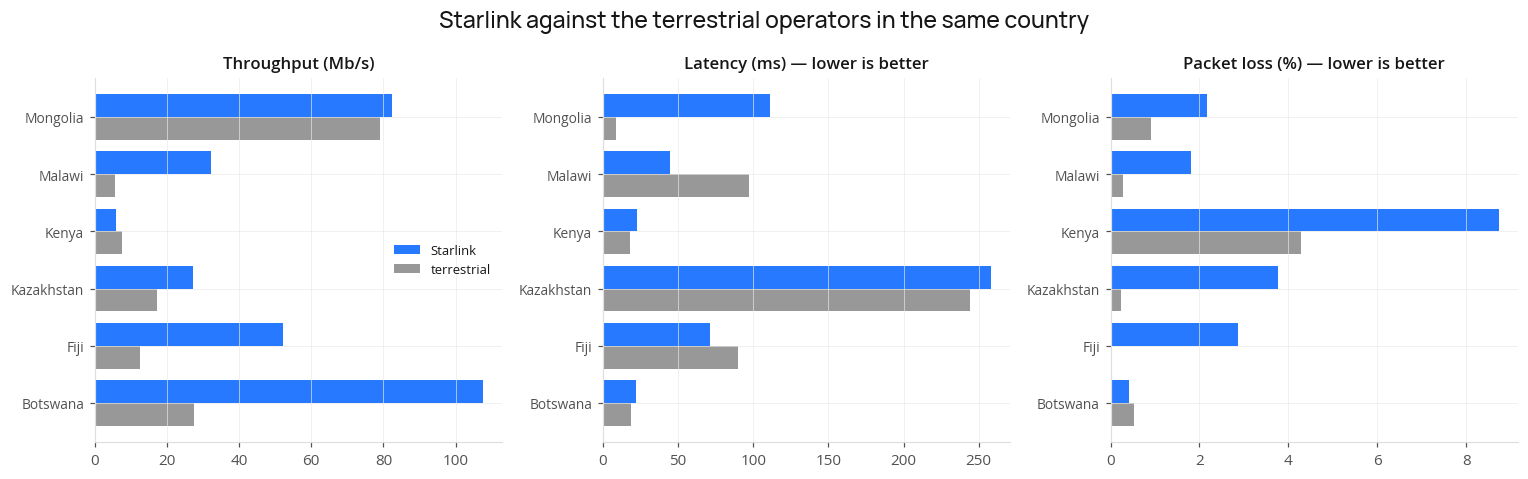

In [7]:
# =============================================================================
# Q3 — WHERE IT WINS AND WHERE IT LOSES
# =============================================================================
_w = routing.pivot(index='country', columns='kind',
                   values=['median_rtt_ms', 'median_mbps', 'median_loss_pct'])
_w.columns = [f"{a.replace('median_', '')}_{b[:4]}" for a, b in _w.columns]
_w['mbps_ratio'] = (_w['mbps_star'] / _w['mbps_terr']).round(2)
_w['rtt_ratio'] = (_w['rtt_ms_star'] / _w['rtt_ms_terr']).round(2)
_w['loss_ratio'] = (_w['loss_pct_star'] / _w['loss_pct_terr'].replace(0, float('nan'))).round(1)
display(_w)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (col_s, col_t, title, invert) in zip(axes, [
        ('mbps_star', 'mbps_terr', 'Throughput (Mb/s)', False),
        ('rtt_ms_star', 'rtt_ms_terr', 'Latency (ms) — lower is better', True),
        ('loss_pct_star', 'loss_pct_terr', 'Packet loss (%) — lower is better', True)]):
    _idx = range(len(_w))
    ax.barh([i + 0.2 for i in _idx], _w[col_s], height=0.4, color=GIGA_BLUE, label='Starlink')
    ax.barh([i - 0.2 for i in _idx], _w[col_t], height=0.4, color=GIGA_GREY[500], label='terrestrial')
    ax.set_yticks(list(_idx)); ax.set_yticklabels(_w.index, fontsize=9)
    ax.set_title(title, fontsize=11)
axes[0].legend(fontsize=8.5)
fig.suptitle('Starlink against the terrestrial operators in the same country')
plt.tight_layout(); plt.show()

---
## Q4 — Is the capacity contended?

A wide swing between the best and worst hour of the school day means capacity
is shared under load. Comparing the two kinds *within* a country holds the
schools, the calendar and the destination roughly constant.

In [8]:
# =============================================================================
# Q4 — CONGESTION ACROSS THE SCHOOL DAY
# =============================================================================
profile = congestion_profile(countries=sorted(COMPARE.values()))
congestion = congestion_summary(profile)
congestion.insert(1, 'country', congestion['iso3'].map(lambda c: NAME.get(c, c)[:18]))
display(congestion)

_pair = congestion.pivot(index='country', columns='kind', values='mbps_swing_pct').dropna()
print("Throughput swing across the school day, Starlink vs terrestrial:")
for country, row in _pair.iterrows():
    print(f"   {country:<18} starlink {row['starlink']:>3.0f}%   terrestrial {row['terrestrial']:>3.0f}%")
print("\nStarlink is the more contended of the two almost everywhere. It does not")
print("follow that schools are worse off: compare its worst hour with the")
print("terrestrial best hour in the same country.")

_worst = congestion.pivot(index='country', columns='kind', values='mbps_worst')
_best = congestion.pivot(index='country', columns='kind', values='mbps_best')
for country in _worst.dropna().index:
    print(f"   {country:<18} starlink at its worst {_worst.loc[country, 'starlink']:>6.1f} "
          f"vs terrestrial at its best {_best.loc[country, 'terrestrial']:>6.1f} Mb/s")

,iso3,country,kind,tests,mbps_best,mbps_worst,mbps_swing_pct,rtt_best,rtt_worst,median_loss_pct
0,BWA,Botswana,starlink,4310,179.3,84.7,53,21.4,23.0,0.32
1,BWA,Botswana,terrestrial,22239,40.3,26.7,34,17.8,19.4,0.30
2,FJI,Fiji,starlink,8511,72.5,29.4,59,70.2,75.0,2.42
3,FJI,Fiji,terrestrial,80985,16.0,9.5,41,89.9,93.2,0.01
4,KAZ,Kazakhstan,starlink,14491,30.4,26.6,13,255.2,260.9,3.16
5,KAZ,Kazakhstan,terrestrial,79818,19.3,15.1,22,222.6,231.1,0.08
6,KEN,Kenya,terrestrial,8317,9.9,7.3,26,14.4,17.9,2.12
7,MNG,Mongolia,starlink,8529,92.9,70.8,24,107.8,109.7,1.99
8,MNG,Mongolia,terrestrial,208168,84.4,72.5,14,5.5,15.8,1.56
9,MWI,Malawi,starlink,10666,39.5,16.2,59,44.7,56.9,1.53


Throughput swing across the school day, Starlink vs terrestrial:
   Botswana           starlink  53%   terrestrial  34%
   Fiji               starlink  59%   terrestrial  41%
   Kazakhstan         starlink  13%   terrestrial  22%
   Malawi             starlink  59%   terrestrial  34%
   Mongolia           starlink  24%   terrestrial  14%

Starlink is the more contended of the two almost everywhere. It does not
follow that schools are worse off: compare its worst hour with the
terrestrial best hour in the same country.
   Botswana           starlink at its worst   84.7 vs terrestrial at its best   40.3 Mb/s
   Fiji               starlink at its worst   29.4 vs terrestrial at its best   16.0 Mb/s
   Kazakhstan         starlink at its worst   26.6 vs terrestrial at its best   19.3 Mb/s
   Malawi             starlink at its worst   16.2 vs terrestrial at its best    6.3 Mb/s
   Mongolia           starlink at its worst   70.8 vs terrestrial at its best   84.4 Mb/s


---
## Q5 — Comparing the technology, not the schools

Everything above compares Starlink schools with terrestrial schools. In Malawi
those are not comparable populations: the Starlink estate is a programme fleet,
75% rural against 53% for terrestrial, and it was placed where connectivity was
worst. A cross-sectional gap of that kind measures the selection as much as the
technology.

Some schools measured on both links. Each is its own control — same building,
same region, same curriculum — and the connection is the only thing that
changes.

In [9]:
# =============================================================================
# Q5 — WITHIN-SCHOOL COMPARISON (MALAWI)
# =============================================================================
try:
    within = within_school_comparison('MWI', min_tests=20)
    display(within[['school_name', 'school_area_type', 'tests_terr', 'tests_star',
                    'median_mbps_terr', 'median_mbps_star', 'mbps_gain',
                    'median_rtt_terr', 'median_rtt_star']].round(2))
    verdict = within_school_verdict(within)
    for _k, _v in verdict.items():
        print(f"   {_k:34s} {_v}")
except Exception as _e:
    within = None
    print(f"Needs Trino ({type(_e).__name__}: {_e})")

,school_name,school_area_type,tests_terr,tests_star,median_mbps_terr,median_mbps_star,mbps_gain,median_rtt_terr,median_rtt_star
0,Chizumulu CDSS,Rural,56.0,51.0,1.43,39.87,38.44,109.83,240.88
1,St Paul's Anglican,Rural,98.0,24.0,4.24,40.75,36.51,80.80,220.00
2,Chankhomi CDSS,Urban,94.0,141.0,0.83,30.75,29.91,52.66,50.02
3,Phalombe,Rural,73.0,404.0,3.73,28.88,25.15,76.56,178.95
4,New Life Tabernacle private school,Ubarn,94.0,100.0,6.99,30.63,23.64,80.50,89.20
5,Chisala CDSS,Rural,33.0,283.0,6.50,24.74,18.24,150.00,224.86
6,Kuwala Christian Girls,Rural,77.0,415.0,11.49,25.69,14.20,96.69,224.92
7,Bambino,Urban,53.0,405.0,11.40,18.17,6.76,79.25,214.69
8,Rumphi Secondary school,Urban,246.0,191.0,0.49,0.93,0.44,73.25,110.33
9,Nkolokoti CCAP,Urban,101.0,21.0,1.55,1.35,-0.20,87.96,64.00


   schools                            18
   median_mbps_terrestrial            4.89
   median_mbps_starlink               8.54
   median_mbps_gain                   0.12
   schools_faster_on_starlink         9
   median_rtt_gain_ms                 -28.9
   schools_lower_latency_on_starlink  6
   wilcoxon_p_mbps                    0.22875213623046875


Malawi, median download:
   across schools   terrestrial    5.6 -> starlink   32.3 Mb/s
   within schools   terrestrial    4.9 -> starlink    8.5 Mb/s

   9 of 18 schools faster on Starlink; Wilcoxon p=0.23
   6 of 18 lower-latency on Starlink (median -28.9 ms)

   gain vs the school's terrestrial speed : rho=-0.48, p=0.043
   Starlink speed vs terrestrial speed    : rho=+0.11, p=0.657

   Starlink delivers >=15 Mb/s at 8 of 18 schools (median 29.8)
   and under 5 Mb/s at 9 (median 1.6)

The installs are bimodal: a school gets either roughly 30 Mb/s or under 5,
and which one is not predicted by its terrestrial speed. So this is a property
of the Starlink link itself — obstruction, service tier, terminal or sharing —
and not of the line it replaced. Rural installs fall in the fast group and
urban ones mostly do not, which is what drives the rural/urban split; 18
schools cannot say why.


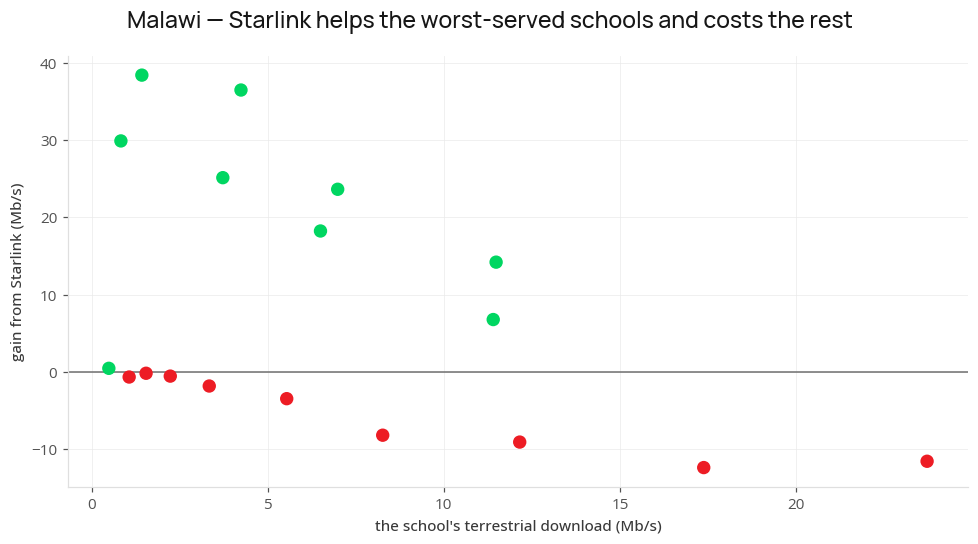

In [10]:
# =============================================================================
# Q5b — THE CROSS-SECTIONAL GAP AGAINST THE WITHIN-SCHOOL ONE
# =============================================================================
if within is not None and len(within):
    _cross = routing[routing['country'].str.startswith('Malawi')].set_index('kind')
    print("Malawi, median download:")
    print(f"   across schools   terrestrial {_cross.loc['terrestrial','median_mbps']:>6.1f} "
          f"-> starlink {_cross.loc['starlink','median_mbps']:>6.1f} Mb/s")
    print(f"   within schools   terrestrial {verdict['median_mbps_terrestrial']:>6.1f} "
          f"-> starlink {verdict['median_mbps_starlink']:>6.1f} Mb/s")
    print(f"\n   {verdict['schools_faster_on_starlink']} of {verdict['schools']} schools "
          f"faster on Starlink; Wilcoxon p={verdict['wilcoxon_p_mbps']:.2f}")
    print(f"   {verdict['schools_lower_latency_on_starlink']} of {verdict['schools']} "
          f"lower-latency on Starlink (median {verdict['median_rtt_gain_ms']:+.1f} ms)")

    from scipy import stats as _st
    _rho_gain, _p_gain = _st.spearmanr(within['median_mbps_terr'], within['mbps_gain'])
    _rho_abs, _p_abs = _st.spearmanr(within['median_mbps_terr'], within['median_mbps_star'])
    print(f"\n   gain vs the school's terrestrial speed : rho={_rho_gain:+.2f}, p={_p_gain:.3f}")
    print(f"   Starlink speed vs terrestrial speed    : rho={_rho_abs:+.2f}, p={_p_abs:.3f}")

    _fast = within[within['median_mbps_star'] >= 15]
    _slow = within[within['median_mbps_star'] < 15]
    print(f"\n   Starlink delivers >=15 Mb/s at {len(_fast)} of {len(within)} schools "
          f"(median {_fast['median_mbps_star'].median():.1f})")
    print(f"   and under 5 Mb/s at {int((within['median_mbps_star'] < 5).sum())} "
          f"(median {_slow['median_mbps_star'].median():.1f})")
    print("\nThe installs are bimodal: a school gets either roughly 30 Mb/s or under 5,")
    print("and which one is not predicted by its terrestrial speed. So this is a property")
    print("of the Starlink link itself — obstruction, service tier, terminal or sharing —")
    print("and not of the line it replaced. Rural installs fall in the fast group and")
    print("urban ones mostly do not, which is what drives the rural/urban split; 18")
    print("schools cannot say why.")

    fig, ax = plt.subplots(figsize=(9, 5))
    _c = [GIGA_GOOD if g > 0 else GIGA_BAD for g in within['mbps_gain']]
    ax.scatter(within['median_mbps_terr'], within['mbps_gain'], s=60, color=_c, zorder=3)
    ax.axhline(0, color=GIGA_GREY[600], linewidth=1)
    ax.set_xlabel("the school's terrestrial download (Mb/s)")
    ax.set_ylabel('gain from Starlink (Mb/s)')
    fig.suptitle('Malawi — Starlink helps the worst-served schools and costs the rest')
    plt.tight_layout(); plt.show()

---
## What can be said about Starlink as a school ISP

**Ground-station placement explains the routing.** Where Starlink hands off
inside the country — Kenya in Nairobi, Kazakhstan in Almaty — its latency sits
close to terrestrial. Where it hands off abroad, the detour is the whole story:
Mongolia's traffic goes to Tokyo and back for a server in Ulaanbaatar, 111 ms
against terrestrial's 8.7, and Botswana's crosses to Johannesburg via the
United States.

**It substitutes for missing international capacity, not for domestic
infrastructure.** Where the terrestrial route abroad is poor, Starlink beats it.
Where a domestic server exists and terrestrial reaches it directly, Starlink's
detour is a straight penalty.

**The size of its advantage is mostly selection.** Across schools in Malawi,
Starlink reads 32.3 Mb/s against 5.6. Within the 18 schools that measured on
both links, the median gain is about +0.1 Mb/s and 9 of 18 are faster —
indistinguishable from a coin flip (Wilcoxon p = 0.23).

**And the installs themselves are bimodal.** A school gets either roughly
30 Mb/s from Starlink or under 5, with little in between, and which one it gets
is not predicted by its terrestrial speed (rho = +0.11, p = 0.66). That points
at the link — obstruction, service tier, terminal, or a dish shared across a
site — rather than at the line it replaced. The five rural schools all fall in
the fast group and most urban ones do not, which is what produces the
rural/urban split; eighteen schools cannot say why.

**Within the same school it is slower, not faster, on latency** — a median
22 ms worse, and better on only 6 of 18. The cross-sectional comparison hid
that behind the rural/urban split.

**It buys throughput and pays in packet loss.** Loss runs consistently higher —
Fiji 2.4% against 0.01%, Kazakhstan 3.2% against 0.08%. For a download that
trade is good; for a video lesson loss is what breaks the call, and no
procurement written in Mb/s will see it.

### What this cannot answer

* **Cost**, which the comparison is meaningless without.
* **Whether a school kept both links.** Some of the within-school pairs overlap
  in time rather than succeeding one another, so "before and after" is not
  always the right reading of them.
* **Whether terrestrial would have improved anyway** — these are observational
  comparisons between operators, not an experiment.
* **Loss under load.** It is reported as a period median; whether it spikes
  during lessons is a different measurement.